# NLP - Assignment 2 - PS3

### Group ID:
Group ID: Group 142
### Group Members Name with Student ID:
1. Rahul Agarwal - 2024AA05676 - 100%
2. Ruchi Kesharwani - 2024AB05678 - 100%
3. Sasane Gauri Ramesh - 2024AA05679 - 100%
4. Aman Singh- 2024AA05301 - 100%
5. Thakare Jayashri Dilip - 2024AA05680 - 100%

Dataset: https://drive.google.com/file/d/15Wmi3GyCeEX6w8N528S40OYCnRhInH5W/view

Description of Data: 
The data set is intended for advancing financial sentiment analysis research

### 1. (5 Marks) (Mention suitable assumptions if necessary.) 

### a. Download the dataset and Create a dataframe named as fsa, then check the head, info, and describe methods on created dataframe fsa.              (0.5 Mark)

In [1]:
%conda install -y pandas
%conda install -y nltk
%conda install -y matplotlib
%conda install -y seaborn

Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.wsd import lesk
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fsa = pd.read_csv('dataset\FinancialSentimentAnalysis.csv')

In [4]:
fsa.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [5]:
fsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [6]:
fsa.describe()

,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,Net sales decreased to EUR 220.5 mn from EUR 4...,neutral
freq,2,3130


### b. Perform  pre-processing  steps  like  Removing  Punctuations,  Numbers, and Special Characters, Stop Words in dataset.  (0.5 Mark)

In [7]:
# Remove Punctuations, Numbers, and Special Characters, Stop Words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = ''.join([i for i in text if not i.isdigit()])
    # Remove special characters
    text = ''.join([i for i in text if i.isalpha() or i.isspace()])
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aman_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
fsa['cleaned_sentence'] = fsa['Sentence'].apply(preprocess_text)

In [9]:
fsa.head()

,Sentence,Sentiment,cleaned_sentence
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon gps s...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi lows bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sales doubled eurm...
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...


### c. Normalize Sentence column by using Stemming or Lemmatization. (0.5 Mark)

In [10]:
# Lemmatization
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

fsa['cleaned_sentence'] = fsa['cleaned_sentence'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aman_\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
fsa.head()

,Sentence,Sentiment,cleaned_sentence
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon gps s...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi low bk real possibility
2,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sale doubled eurm ...
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...


### d. Demonstrate use of Sentiwordnet to calculate the senti_score of each of the reviews. (3.5 Marks)

In [12]:
# Use Sentiwordnet to calculate the senti_score
from nltk.corpus import sentiwordnet as swn
nltk.download('sentiwordnet')

def calculate_senti_score(text):
    words = text.split()
    score = 0
    for word in words:
        synsets = list(swn.senti_synsets(word))
        if synsets:
            score += synsets[0].pos_score() - synsets[0].neg_score()
    return score

[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\aman_\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!


In [13]:
fsa['senti_score'] = fsa['cleaned_sentence'].apply(calculate_senti_score)

In [14]:
fsa.head()

,Sentence,Sentiment,cleaned_sentence,senti_score
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon gps s...,0.625
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi low bk real possibility,0.000
2,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sale doubled eurm ...,-0.125
3,According to the Finnish-Russian Chamber of Co...,neutral,according finnishrussian chamber commerce majo...,-0.125
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining percent sta...,0.000


In [15]:
positive_reviews = fsa[fsa['Sentiment'] == 'positive']
negative_reviews = fsa[fsa['Sentiment'] == 'negative']
neutral_reviews = fsa[fsa['Sentiment'] == 'neutral']

In [16]:
positive_reviews.count()

Sentence            1852
Sentiment           1852
cleaned_sentence    1852
senti_score         1852
dtype: int64

In [17]:
negative_reviews.count()

Sentence            860
Sentiment           860
cleaned_sentence    860
senti_score         860
dtype: int64

In [18]:
neutral_reviews.count()

Sentence            3130
Sentiment           3130
cleaned_sentence    3130
senti_score         3130
dtype: int64

We have a lot more `neutral` reviews in the dataset `(3130)`, compared to the `positive` reviews `(1852)` and `negative` reviews `(860)`.

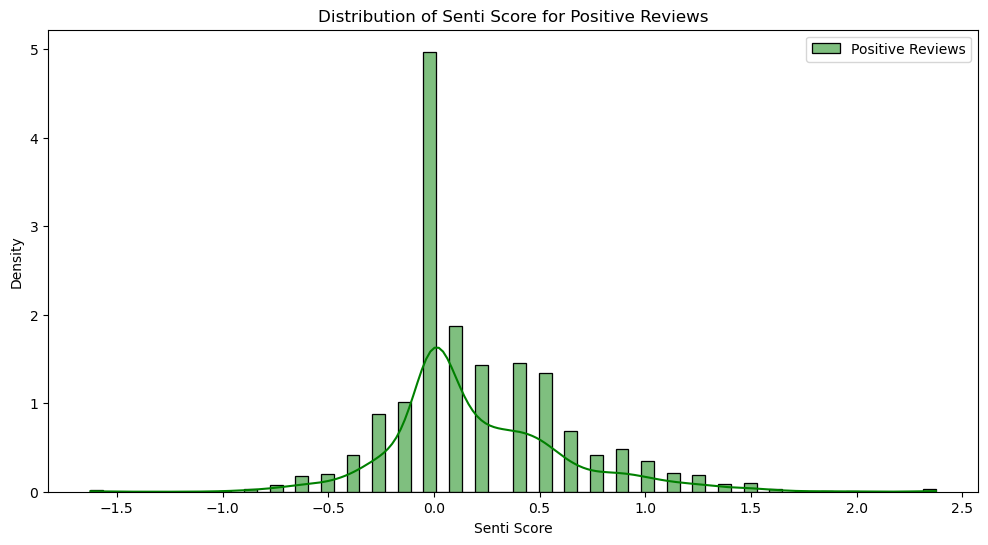

In [19]:
# Plot the distribution of senti_score for positive reviews

plt.figure(figsize=(12, 6))
sns.histplot(positive_reviews['senti_score'], color='green', label='Positive Reviews', kde=True, stat='density')
plt.title('Distribution of Senti Score for Positive Reviews')
plt.xlabel('Senti Score')
plt.ylabel('Density')
plt.legend()
plt.show()

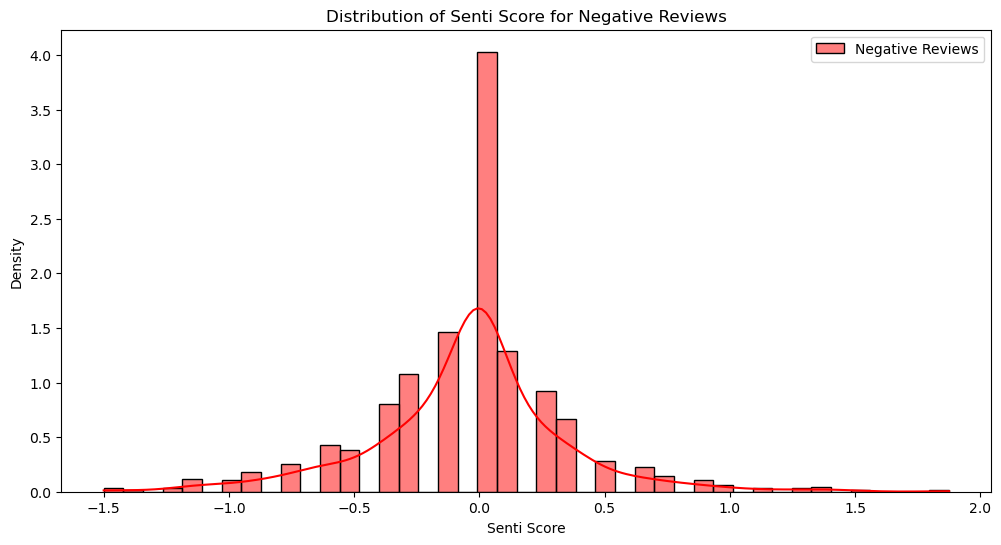

In [20]:
# Plot the distribution of senti_score for negative reviews

plt.figure(figsize=(12, 6))
sns.histplot(negative_reviews['senti_score'], color='red', label='Negative Reviews', kde=True, stat='density')
plt.title('Distribution of Senti Score for Negative Reviews')
plt.xlabel('Senti Score')
plt.ylabel('Density')
plt.legend()
plt.show()

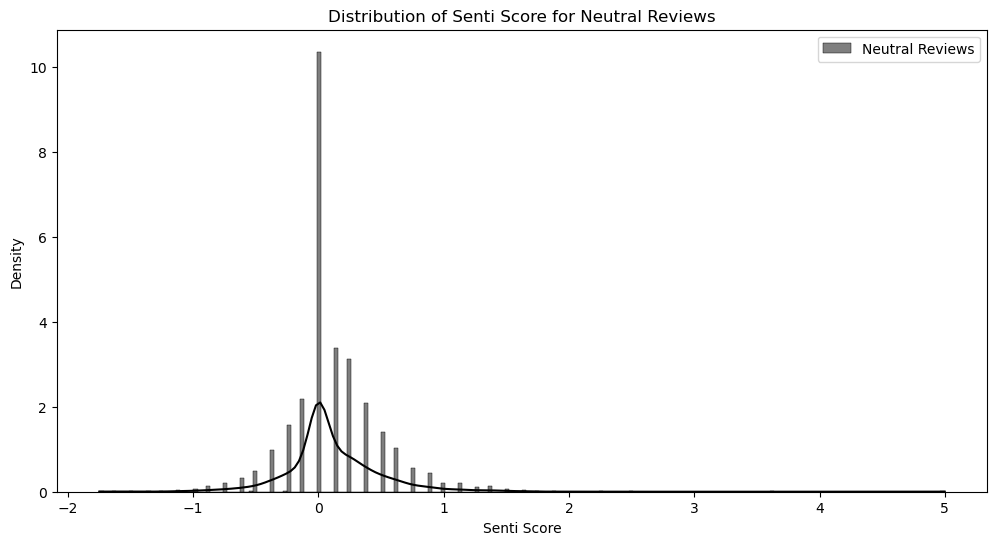

In [21]:
# Plot the distribution of senti_score for neutral reviews

plt.figure(figsize=(12, 6))
sns.histplot(neutral_reviews['senti_score'], color='black', label='Neutral Reviews', kde=True, stat='density') 
plt.title('Distribution of Senti Score for Neutral Reviews')
plt.xlabel('Senti Score')
plt.ylabel('Density')
plt.legend()
plt.show()

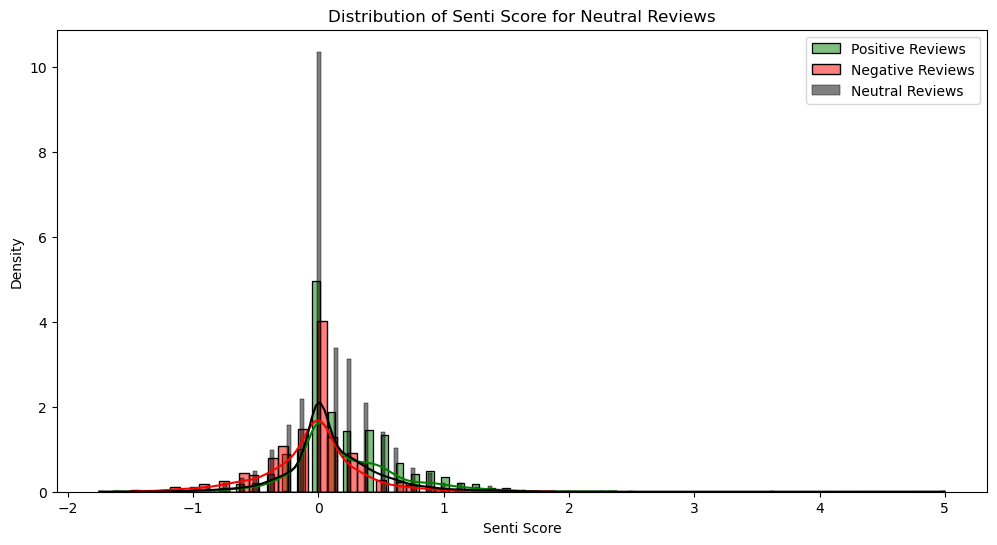

In [22]:
# Plot the distribution of senti_score for all kinds of reviews

plt.figure(figsize=(12, 6))
sns.histplot(positive_reviews['senti_score'], color='green', label='Positive Reviews', kde=True, stat='density') 
sns.histplot(negative_reviews['senti_score'], color='red', label='Negative Reviews', kde=True, stat='density') 
sns.histplot(neutral_reviews['senti_score'], color='black', label='Neutral Reviews', kde=True, stat='density') 
plt.title('Distribution of Senti Score for Neutral Reviews')
plt.xlabel('Senti Score')
plt.ylabel('Density')
plt.legend()
plt.show()

We can see in this graph:
1. The density of `negative reviews` in reviews having `senti_score < 0` is `higher` compared to positive or neutral reviews (red line is higher compared to black and green lines when senti_score < 0), meaning that reviews with `less senti_score (< 0)` are more `likely to be negative reviews`.
2. The density of `positive reviews` in reviews having `senti_score > 0` is `higher` compared to negative or neutral reviews (green line is higher compared to black and red lines when senti_score > 0), meaning that reviews with `high senti_score (> 0)` are more `likely to be positive reviews`.
3. The density of `neutral reviews` in reviews having `senti_score = 0` is `higher` compared to positive or negative reviews (black line is higher compared to red and green when senti_score = 0), meaning that reviews with `senti_score = 0` are more `likely to be neutral reviews`.

The observations are despite the fact that the distribution of reviews of different sentiments is skewed (neutral > positive > negative).

### 2. Take some sample reviews from the dataset and demonstrate the following: (5 Marks) 

### a. Synsets

In [23]:
sample_reviews = fsa.sample(5)

In [29]:
# Identify synsets from some sample reviews

for review in sample_reviews['cleaned_sentence']:
    print(f"Review: {review}")

    for word in review.split():
        synsets = list(swn.senti_synsets(word))

        if len(synsets) > 0:
            print(f"  Word: {word}")
            for word_synset in synsets:
                print(f"    Synset: {word_synset.synset.name()}, Positive Score: {word_synset.pos_score()}, Negative Score: {word_synset.neg_score()}")

Review: finnish insurance company fennia kesko group ending loyal customer cooperation
  Word: finnish
    Synset: finnish.n.01, Positive Score: 0.0, Negative Score: 0.0
    Synset: finnish.a.01, Positive Score: 0.0, Negative Score: 0.0
  Word: insurance
    Synset: insurance.n.01, Positive Score: 0.0, Negative Score: 0.0
    Synset: policy.n.03, Positive Score: 0.0, Negative Score: 0.0
    Synset: indemnity.n.01, Positive Score: 0.0, Negative Score: 0.0
  Word: company
    Synset: company.n.01, Positive Score: 0.0, Negative Score: 0.0
    Synset: company.n.02, Positive Score: 0.0, Negative Score: 0.0
    Synset: company.n.03, Positive Score: 0.0, Negative Score: 0.0
    Synset: company.n.04, Positive Score: 0.0, Negative Score: 0.0
    Synset: caller.n.01, Positive Score: 0.0, Negative Score: 0.0
    Synset: company.n.06, Positive Score: 0.0, Negative Score: 0.0
    Synset: party.n.03, Positive Score: 0.0, Negative Score: 0.0
    Synset: ship's_company.n.01, Positive Score: 0.0, Negat

Here we can see the synsets for each word of the sample reviews. We can see each of the synonymous words for the review words, along with the sentiment scores for the synonymous words.

The names of the synsets include the synonymous word, along with the pos tag for the word and the sense index.

### b. Synonyms and Antonyms

In [25]:
# Identify synonyms and antonyms from some sample reviews
for review in sample_reviews['cleaned_sentence']:
    print(f"Review: {review}")
    for word in review.split():
        synsets = list(swn.senti_synsets(word))
        if len(synsets) > 0:
            print(f"Word: {word}")
            for synset in synsets:
                print(f"  Synset: {synset.synset.name()}")
                print(f"    Synonyms:")
                for lemma in synset.synset.lemmas():
                    print(f"      Lemma: {lemma.name()}")
                print(f"    Antonyms:")
                for lemma in synset.synset.lemmas():
                    for antonym in lemma.antonyms():
                        print(f"      Lemma: {antonym.name()}")



Review: finnish insurance company fennia kesko group ending loyal customer cooperation
Word: finnish
  Synset: finnish.n.01
    Synonyms:
      Lemma: Finnish
      Lemma: Suomi
    Antonyms:
  Synset: finnish.a.01
    Synonyms:
      Lemma: Finnish
    Antonyms:
Word: insurance
  Synset: insurance.n.01
    Synonyms:
      Lemma: insurance
    Antonyms:
  Synset: policy.n.03
    Synonyms:
      Lemma: policy
      Lemma: insurance_policy
      Lemma: insurance
    Antonyms:
  Synset: indemnity.n.01
    Synonyms:
      Lemma: indemnity
      Lemma: insurance
    Antonyms:
Word: company
  Synset: company.n.01
    Synonyms:
      Lemma: company
    Antonyms:
  Synset: company.n.02
    Synonyms:
      Lemma: company
    Antonyms:
  Synset: company.n.03
    Synonyms:
      Lemma: company
      Lemma: companionship
      Lemma: fellowship
      Lemma: society
    Antonyms:
  Synset: company.n.04
    Synonyms:
      Lemma: company
      Lemma: troupe
    Antonyms:
  Synset: caller.n.01
    Sy

Here, we're trying to find the synonyms and antonyms of the synsets of the words in the reviews. Wordnet contains a bunch of synonyms for the words, but in our observation, it doesn't contain the antonyms for a lot of words.

Here's an example we found of a synset with both synonyms and antonyms from the dataset.

```
  Synset: converge.v.01
    Synonyms:
      Lemma: converge
      Lemma: meet
    Antonyms:
      Lemma: diverge
      Lemma: diverge
```

### c. Hyponym and Hypernym

In [26]:
# Identify hyponyms and hypernyms from some sample reviews
for review in sample_reviews['cleaned_sentence']:
    print(f"Review: {review}")
    for word in review.split():
        synsets = list(swn.senti_synsets(word))
        if len(synsets) > 0:
            print(f"Word: {word}")
            for synset in synsets:
                synset_name = synset.synset.name()
                hyponyms = synset.synset.hyponyms()
                hypernyms = synset.synset.hypernyms()
                print(f"  Synset: {synset_name}")
                print(f"    Hyponyms: {[h.name() for h in hyponyms]}")
                print(f"    Hypernyms: {[h.name() for h in hypernyms]}")
                

Review: finnish insurance company fennia kesko group ending loyal customer cooperation
Word: finnish
  Synset: finnish.n.01
    Hyponyms: []
    Hypernyms: ['baltic-finnic.n.01']
  Synset: finnish.a.01
    Hyponyms: []
    Hypernyms: []
Word: insurance
  Synset: insurance.n.01
    Hyponyms: ['term_insurance.n.01', 'hazard_insurance.n.01', 'coinsurance.n.01', 'fire_insurance.n.01', 'assurance.n.04', 'life_insurance.n.01', 'malpractice_insurance.n.01', 'self-insurance.n.01', 'health_insurance.n.01', 'group_insurance.n.01', 'automobile_insurance.n.01', 'business_interruption_insurance.n.01', 'liability_insurance.n.01', 'reinsurance.n.01']
    Hypernyms: ['security.n.02']
  Synset: policy.n.03
    Hyponyms: ['floater.n.08']
    Hypernyms: ['contract.n.01']
  Synset: indemnity.n.01
    Hyponyms: []
    Hypernyms: ['protection.n.04']
Word: company
  Synset: company.n.01
    Hyponyms: ['livery_company.n.01', 'record_company.n.01', 'electronics_company.n.01', 'subsidiary_company.n.01', 'corpor

Here we're trying to print the Hyponyms and Hypernyms of each of the synsets of the words in the sample reviews. Hyponyms are specific words in the synset word category, while Hypernym represents the more general word for the synset word.

### d. Wordnet path similarity

In [30]:
# Identify wordnet path similarity from some sample reviews
for review in sample_reviews['cleaned_sentence']:
    print(f"Review: {review}")
    for word in review.split():
        synsets = list(swn.senti_synsets(word))
        if len(synsets) > 0:
            print(f"  Word: {word}")

            # Compare each synset for the word with every other synset
            for i in range(len(synsets)):
                for j in range(i + 1, len(synsets)):
                    similarity = synsets[i].synset.wup_similarity(synsets[j].synset)
                    if similarity is not None:
                        print(f"    Synset1: {synsets[i].synset.name()}, Synset2: {synsets[j].synset.name()}, Similarity: {similarity}")


Review: finnish insurance company fennia kesko group ending loyal customer cooperation
  Word: finnish
    Synset1: finnish.n.01, Synset2: finnish.a.01, Similarity: 0.14285714285714285
  Word: insurance
    Synset1: insurance.n.01, Synset2: policy.n.03, Similarity: 0.25
    Synset1: insurance.n.01, Synset2: indemnity.n.01, Similarity: 0.25
    Synset1: policy.n.03, Synset2: indemnity.n.01, Similarity: 0.2222222222222222
  Word: company
    Synset1: company.n.01, Synset2: company.n.02, Similarity: 0.625
    Synset1: company.n.01, Synset2: company.n.03, Similarity: 0.2857142857142857
    Synset1: company.n.01, Synset2: company.n.04, Similarity: 0.7692307692307693
    Synset1: company.n.01, Synset2: caller.n.01, Similarity: 0.14285714285714285
    Synset1: company.n.01, Synset2: company.n.06, Similarity: 0.5714285714285714
    Synset1: company.n.01, Synset2: party.n.03, Similarity: 0.6153846153846154
    Synset1: company.n.01, Synset2: ship's_company.n.01, Similarity: 0.625
    Synset1: c

Here we're trying to print the Wordnet Path Similarities between two synsets of the words in the sample reviews. Higher the similarity, the more semantically closer the two synsets are.

### e. Word sense disambiguation

In [28]:
# Identify word sense disambiguation from some sample reviews
for review in sample_reviews['cleaned_sentence']:
    print(f"Review: {review}")
    for word in review.split():
        sense = lesk(review.split(), word)
        if sense:
            print(f"  Word: {word}, Sense: {sense.name()}, Definition: {sense.definition()}")


Review: finnish insurance company fennia kesko group ending loyal customer cooperation
  Word: finnish, Sense: finnish.n.01, Definition: the official language of Finland; belongs to the Baltic Finnic family of languages
  Word: insurance, Sense: insurance.n.01, Definition: promise of reimbursement in the case of loss; paid to people or companies so concerned about hazards that they have made prepayments to an insurance company
  Word: company, Sense: ship's_company.n.01, Definition: crew of a ship including the officers; the whole force or personnel of a ship
  Word: group, Sense: group.v.02, Definition: form a group or group together
  Word: ending, Sense: termination.n.05, Definition: the act of ending something
  Word: loyal, Sense: patriotic.a.01, Definition: inspired by love for your country
  Word: customer, Sense: customer.n.01, Definition: someone who pays for goods or services
  Word: cooperation, Sense: cooperation.n.02, Definition: the practice of cooperating
Review: loss fi

#### Here we're trying to print the disambiguated meaning of the words in the sample reviews. We're using the `lesk` method of the nltk library to decipher the meaning of the words. When disambiguating, we're providing the entire review as context words to the method.

